# Music Listening Analytics Using PySpark

**Assignment part:** Part A - Big Data Analytics Using Apache Spark

This notebook adds the bonus component for the mini project. It uses the same Last.fm 1K listening-history dataset, but the goal is different from the recommendation notebook. Here, the focus is on big data analytics: discovering listening patterns, temporal trends, country-level user distribution, and user behavior segments.

**Main analytics technique:** PySpark ML KMeans clustering is used to segment listeners based on listening volume, music diversity, repeat behavior, night listening, and weekend listening.

## How this earns bonus marks

The assignment says students who attempt both parts may receive bonus marks. The recommendation notebook covers Part B. This notebook covers Part A by showing:

1. Dataset loading using PySpark.
2. Data cleaning and preprocessing.
3. Exploratory data analysis with visualizations.
4. Big data analytics using Spark transformations and aggregations.
5. A Spark ML clustering model for listener segmentation.
6. Interpretation of results, limitations, and improvements.

## 1. Install and import required libraries

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = ['pyspark', 'pandas', 'matplotlib']

for package_name in REQUIRED_PACKAGES:
    if importlib.util.find_spec(package_name) is None:
        print(f'Installing {package_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

print('Environment is ready.')

Environment is ready.


In [2]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

PROJECT_DIR = Path.cwd()
LOCAL_JAVA_HOME = PROJECT_DIR / '.jdk' / 'jdk-17.0.19+10' / 'Contents' / 'Home'
SPARK_LOCAL_DIR = PROJECT_DIR / 'spark-temp'
MPLCONFIG_DIR = PROJECT_DIR / '.matplotlib'
SPARK_LOCAL_DIR.mkdir(exist_ok=True)
MPLCONFIG_DIR.mkdir(exist_ok=True)

if LOCAL_JAVA_HOME.exists():
    os.environ.setdefault('JAVA_HOME', str(LOCAL_JAVA_HOME))
    os.environ['PATH'] = f"{LOCAL_JAVA_HOME / 'bin'}:{os.environ.get('PATH', '')}"

os.environ.setdefault('SPARK_LOCAL_IP', '127.0.0.1')
os.environ.setdefault('PYSPARK_PIN_THREAD', 'false')
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR))

spark = (
    SparkSession.builder
    .master('local[2]')
    .appName('LastFMListeningAnalytics')
    .config('spark.driver.host', '127.0.0.1')
    .config('spark.driver.bindAddress', '127.0.0.1')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '2g')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.local.dir', str(SPARK_LOCAL_DIR))
    .config('spark.ui.enabled', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
spark.range(1).count()
print('Spark version:', spark.version)

Spark version: 4.0.2


## 2. Dataset setup

The notebook reads the downloaded Last.fm folder from `/Users/sahanpaymedia/Downloads/lastfm-dataset-1K`. The full file has 19,150,868 listening events. For a stable laptop demo, this notebook uses the first 1,000,000 rows by default. Set `MAX_RAW_ROWS = None` to process the full file.

In [3]:
DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

LOCAL_LASTFM_DIR = Path('/Users/sahanpaymedia/Downloads/lastfm-dataset-1K')
LOCAL_TSV_PATH = LOCAL_LASTFM_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv'
LOCAL_PROFILE_PATH = LOCAL_LASTFM_DIR / 'userid-profile.tsv'

PROJECT_TSV_PATH = DATA_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv'
PROJECT_PROFILE_PATH = DATA_DIR / 'userid-profile.tsv'
SAMPLE_PATH = DATA_DIR / 'sample_lastfm_listens.csv'

MAX_RAW_ROWS = 1000000

listen_schema = T.StructType([
    T.StructField('user_id', T.StringType(), True),
    T.StructField('timestamp', T.StringType(), True),
    T.StructField('artist_id', T.StringType(), True),
    T.StructField('artist_name', T.StringType(), True),
    T.StructField('track_id', T.StringType(), True),
    T.StructField('track_name', T.StringType(), True),
])

def read_lastfm_tsv(path):
    return (
        spark.read.schema(listen_schema)
        .option('sep', '\t')
        .option('header', False)
        .option('mode', 'PERMISSIVE')
        .csv(str(path))
    )

if LOCAL_TSV_PATH.exists():
    dataset_source = LOCAL_TSV_PATH
    listens = read_lastfm_tsv(dataset_source)
elif PROJECT_TSV_PATH.exists():
    dataset_source = PROJECT_TSV_PATH
    listens = read_lastfm_tsv(dataset_source)
elif SAMPLE_PATH.exists():
    dataset_source = SAMPLE_PATH
    listens = spark.read.option('header', True).csv(str(SAMPLE_PATH))
else:
    raise FileNotFoundError('Last.fm dataset was not found. Place it in Downloads/lastfm-dataset-1K or in the project data folder.')

if MAX_RAW_ROWS is not None:
    listens = listens.limit(MAX_RAW_ROWS)
    print(f'Using first {MAX_RAW_ROWS:,} rows for this analytics run.')

profile_source = LOCAL_PROFILE_PATH if LOCAL_PROFILE_PATH.exists() else PROJECT_PROFILE_PATH
if profile_source.exists():
    profiles = (
        spark.read.option('sep', '\t')
        .option('header', True)
        .csv(str(profile_source))
        .withColumnRenamed('#id', 'user_id')
    )
else:
    profiles = None

print('Dataset source:', dataset_source)
listens.show(5, truncate=False)

Using first 1,000,000 rows for this analytics run.
Dataset source: /Users/sahanpaymedia/Downloads/lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv
+-----------+--------------------+------------------------------------+-----------+--------+------------------------------------------+
|user_id    |timestamp           |artist_id                           |artist_name|track_id|track_name                                |
+-----------+--------------------+------------------------------------+-----------+--------+------------------------------------------+
|user_000001|2009-05-04T23:08:57Z|f1b1cf71-bd35-4e99-8624-24a6e15f133a|Deep Dish  |NULL    |Fuck Me Im Famous (Pacha Ibiza)-09-28-2007|
|user_000001|2009-05-04T13:54:10Z|a7f7df4a-77d8-4f12-8acd-5c60c93f4de8|坂本龍一   |NULL    |Composition 0919 (Live_2009_4_15)         |
|user_000001|2009-05-04T13:52:04Z|a7f7df4a-77d8-4f12-8acd-5c60c93f4de8|坂本龍一   |NULL    |Mc2 (Live_2009_4_15)                      |
|user_000001|2009-05-04T13:

## 3. Clean and enrich the data

The raw file stores timestamp as text and has some missing track IDs. Missing track IDs are replaced with an artist-title key so each track can still be counted.

In [4]:
expected_columns = ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name']
missing_columns = [column for column in expected_columns if column not in listens.columns]
if missing_columns:
    raise ValueError(f'Missing expected columns: {missing_columns}')

timestamp_clean = F.regexp_replace(F.regexp_replace(F.col('timestamp'), 'T', ' '), 'Z$', '')
track_id_clean = F.when(
    (F.col('track_id').isNotNull()) & (F.length(F.trim(F.col('track_id'))) > 0),
    F.trim(F.col('track_id')),
)
fallback_track_key = F.concat_ws('::', F.lower(F.col('artist_name')), F.lower(F.col('track_name')))

listens_clean = (
    listens.select(*expected_columns)
    .withColumn('user_id', F.trim(F.col('user_id')))
    .withColumn('artist_id', F.trim(F.col('artist_id')))
    .withColumn('artist_name', F.trim(F.col('artist_name')))
    .withColumn('track_id', F.trim(F.col('track_id')))
    .withColumn('track_name', F.trim(F.col('track_name')))
    .withColumn('timestamp', F.to_timestamp(timestamp_clean))
    .where(F.col('user_id').isNotNull() & (F.length(F.col('user_id')) > 0))
    .where(F.col('artist_name').isNotNull() & (F.length(F.col('artist_name')) > 0))
    .where(F.col('track_name').isNotNull() & (F.length(F.col('track_name')) > 0))
    .where(F.col('timestamp').isNotNull())
    .withColumn('track_key', F.coalesce(track_id_clean, fallback_track_key))
    .withColumn('listen_date', F.to_date(F.col('timestamp')))
    .withColumn('listen_hour', F.hour(F.col('timestamp')))
    .withColumn('day_of_week', F.date_format(F.col('timestamp'), 'E'))
    .withColumn('month', F.date_format(F.col('timestamp'), 'yyyy-MM'))
    .dropDuplicates(['user_id', 'timestamp', 'artist_name', 'track_name'])
)

if profiles is not None:
    profiles_clean = (
        profiles.select('user_id', 'gender', 'age', 'country', 'registered')
        .withColumn('user_id', F.trim(F.col('user_id')))
        .withColumn('gender', F.trim(F.col('gender')))
        .withColumn('age', F.col('age').cast('int'))
        .withColumn('country', F.trim(F.col('country')))
        .withColumn('registered', F.to_date(F.col('registered'), 'MMM d, yyyy'))
    )
    listens_enriched = listens_clean.join(profiles_clean, on='user_id', how='left')
else:
    profiles_clean = None
    listens_enriched = listens_clean

listens_clean.cache()
listens_enriched.cache()
listens_clean.show(5, truncate=False)

+-----------+-------------------+------------------------------------+-----------------+------------------------------------+----------------------------------------+------------------------------------+-----------+-----------+-----------+-------+
|user_id    |timestamp          |artist_id                           |artist_name      |track_id                            |track_name                              |track_key                           |listen_date|listen_hour|day_of_week|month  |
+-----------+-------------------+------------------------------------+-----------------+------------------------------------+----------------------------------------+------------------------------------+-----------+-----------+-----------+-------+
|user_000001|2006-08-13 13:59:20|09a114d9-7723-4e14-b524-379697f6d2b5|Plaid & Bob Jaroc|c4633ab1-e715-477f-8685-afa5f2058e42|The Launching Of Big Face               |c4633ab1-e715-477f-8685-afa5f2058e42|2006-08-13 |13         |Sun        |2006-08|
|user_00

## 4. Dataset summary

In [5]:
date_range = listens_clean.agg(
    F.min('listen_date').alias('start_date'),
    F.max('listen_date').alias('end_date'),
).first()

summary_rows = [
    ('listening_events', str(listens_clean.count())),
    ('unique_users', str(listens_clean.select('user_id').distinct().count())),
    ('unique_artists', str(listens_clean.select('artist_name').distinct().count())),
    ('unique_tracks', str(listens_clean.select('track_key').distinct().count())),
    ('date_range', f"{date_range['start_date']} to {date_range['end_date']}"),
]

if profiles_clean is not None:
    profile_user_count = profiles_clean.select('user_id').distinct().count()
    country_count = profiles_clean.where(F.col('country').isNotNull() & (F.length(F.col('country')) > 0)).select('country').distinct().count()
    summary_rows.extend([
        ('profile_users', str(profile_user_count)),
        ('profile_countries', str(country_count)),
    ])

summary_pd = spark.createDataFrame(summary_rows, ['metric', 'value']).toPandas()
display(summary_pd)

,metric,value
0,listening_events,1000000
1,unique_users,41
2,unique_artists,23007
3,unique_tracks,159093
4,date_range,2005-02-28 to 2009-06-19
5,profile_users,992
6,profile_countries,66


## 5. Popular artists and tracks

,artist_name,listen_events
0,Kanye West,27267
1,Dir En Grey,12006
2,ムック,7789
3,Radiohead,7157
4,Nine Inch Nails,6711
5,Muse,6052
6,雅-Miyavi-,6018
7,T.I.,5394
8,Akira Yamaoka,5028
9,Sloan,4993


,artist_name,track_name,listen_events
0,Kanye West,See You In My Nightmares,2069
1,Kanye West,Say You Will,2065
2,Kanye West,Heartless,2063
3,Kanye West,Love Lockdown,2062
4,Kanye West,Welcome To Heartbreak (Feat. Kid Cudi),2059
5,Kanye West,Coldest Winter,2052
6,Kanye West,Paranoid (Feat. Mr. Hudson),2051
7,Kanye West,Amazing (Feat. Young Jeezy),2049
8,Kanye West,Pinocchio Story (Freestyle Live From Singapore),2041
9,Kanye West,Bad News,2026


/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6935/1243256340.py:26: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6935/1243256340.py:26: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6935/1243256340.py:26: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6935/1243256340.py:26: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/sahanpaymedia/Documents/Assignment BigData/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

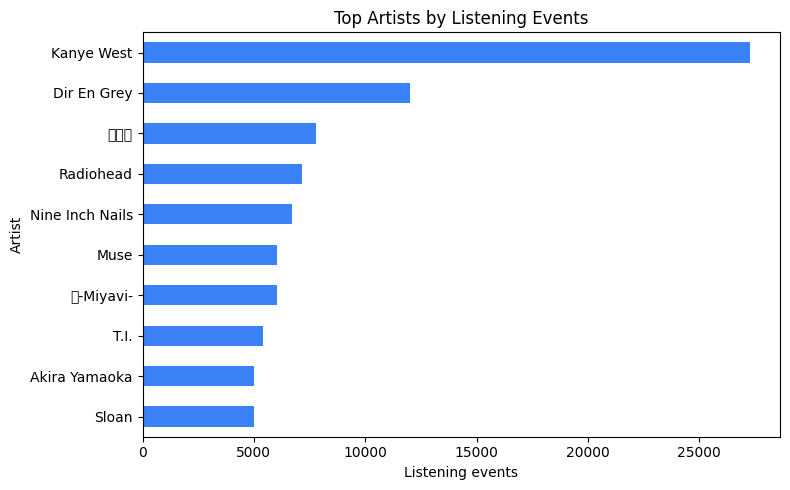

In [6]:
top_artists = (
    listens_clean.groupBy('artist_name')
    .agg(F.count('*').alias('listen_events'))
    .orderBy(F.desc('listen_events'))
    .limit(10)
    .toPandas()
)

top_tracks = (
    listens_clean.groupBy('artist_name', 'track_name')
    .agg(F.count('*').alias('listen_events'))
    .orderBy(F.desc('listen_events'))
    .limit(10)
    .toPandas()
)

display(top_artists)
display(top_tracks)

ax = top_artists.sort_values('listen_events').plot(
    kind='barh', x='artist_name', y='listen_events', legend=False, figsize=(8, 5), color='#3b82f6'
)
ax.set_title('Top Artists by Listening Events')
ax.set_xlabel('Listening events')
ax.set_ylabel('Artist')
plt.tight_layout()
plt.show()

## 6. Temporal listening patterns

This analysis checks when users listen to music most often.

,listen_hour,listen_events
0,0,41578
1,1,37746
2,2,34492
3,3,31120
4,4,28164


,day_of_week,listen_events
6,Mon,141259
1,Tue,142735
2,Wed,137821
3,Thu,138531
4,Fri,140578
5,Sat,149135
0,Sun,149941


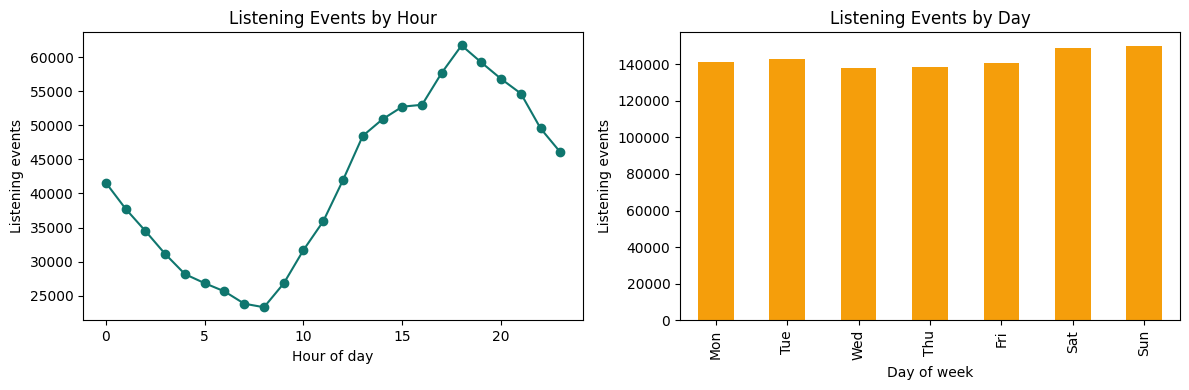

In [7]:
hourly_listens = (
    listens_clean.groupBy('listen_hour')
    .agg(F.count('*').alias('listen_events'))
    .orderBy('listen_hour')
    .toPandas()
)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_listens = (
    listens_clean.groupBy('day_of_week')
    .agg(F.count('*').alias('listen_events'))
    .toPandas()
)
daily_listens['day_of_week'] = pd.Categorical(daily_listens['day_of_week'], categories=day_order, ordered=True)
daily_listens = daily_listens.sort_values('day_of_week')

monthly_listens = (
    listens_clean.groupBy('month')
    .agg(F.count('*').alias('listen_events'))
    .orderBy('month')
    .toPandas()
)

display(hourly_listens.head())
display(daily_listens)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hourly_listens.plot(kind='line', x='listen_hour', y='listen_events', marker='o', ax=axes[0], legend=False, color='#0f766e')
axes[0].set_title('Listening Events by Hour')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Listening events')

daily_listens.plot(kind='bar', x='day_of_week', y='listen_events', ax=axes[1], legend=False, color='#f59e0b')
axes[1].set_title('Listening Events by Day')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Listening events')
plt.tight_layout()
plt.show()

## 7. Country-level listener analysis

In [8]:
if profiles_clean is not None:
    top_countries = (
        profiles_clean.where(F.col('country').isNotNull() & (F.length(F.col('country')) > 0))
        .groupBy('country')
        .agg(F.countDistinct('user_id').alias('users'))
        .orderBy(F.desc('users'))
        .limit(10)
        .toPandas()
    )
    country_listens = (
        listens_enriched.where(F.col('country').isNotNull() & (F.length(F.col('country')) > 0))
        .groupBy('country')
        .agg(F.count('*').alias('listen_events'), F.countDistinct('user_id').alias('active_users'))
        .withColumn('listens_per_user', F.round(F.col('listen_events') / F.col('active_users'), 2))
        .orderBy(F.desc('listen_events'))
        .limit(10)
        .toPandas()
    )
else:
    top_countries = pd.DataFrame(columns=['country', 'users'])
    country_listens = pd.DataFrame(columns=['country', 'listen_events', 'active_users', 'listens_per_user'])

display(top_countries)
display(country_listens)

,country,users
0,United States,228
1,United Kingdom,126
2,Poland,50
3,Germany,36
4,Norway,35
5,Finland,32
6,Canada,32
7,Turkey,28
8,Italy,27
9,Sweden,24


,country,listen_events,active_users,listens_per_user
0,United States,210395,9,23377.22
1,United Kingdom,112643,5,22528.60
2,Poland,103010,2,51505.00
3,Canada,70446,1,70446.00
4,Germany,65651,3,21883.67
5,Peru,57438,1,57438.00
6,Sweden,47363,2,23681.50
7,Turkey,45308,1,45308.00
8,Russian Federation,43394,2,21697.00
9,Slovakia,37235,1,37235.00


## 8. Feature engineering for user segmentation

Each user is described using behavioral features. These features are then used for clustering.

In [9]:
user_features = (
    listens_clean.groupBy('user_id')
    .agg(
        F.count('*').alias('total_listens'),
        F.countDistinct('artist_name').alias('unique_artists'),
        F.countDistinct('track_key').alias('unique_tracks'),
        F.countDistinct('listen_date').alias('active_days'),
        F.sum(F.when((F.col('listen_hour') >= 0) & (F.col('listen_hour') <= 5), 1).otherwise(0)).alias('night_listens'),
        F.sum(F.when(F.col('day_of_week').isin('Sat', 'Sun'), 1).otherwise(0)).alias('weekend_listens'),
    )
    .withColumn('avg_listens_per_day', F.col('total_listens') / F.col('active_days'))
    .withColumn('artist_diversity', F.col('unique_artists') / F.col('total_listens'))
    .withColumn('track_diversity', F.col('unique_tracks') / F.col('total_listens'))
    .withColumn('repeat_rate', 1 - F.col('track_diversity'))
    .withColumn('night_share', F.col('night_listens') / F.col('total_listens'))
    .withColumn('weekend_share', F.col('weekend_listens') / F.col('total_listens'))
)

artist_counts = listens_clean.groupBy('user_id', 'artist_name').agg(F.count('*').alias('artist_listens'))
artist_window = Window.partitionBy('user_id').orderBy(F.desc('artist_listens'), F.asc('artist_name'))
favorite_artists = (
    artist_counts.withColumn('rank', F.row_number().over(artist_window))
    .where(F.col('rank') == 1)
    .select('user_id', F.col('artist_name').alias('favorite_artist'), 'artist_listens')
)

user_features = user_features.join(favorite_artists, on='user_id', how='left')
user_features.cache()
user_features.orderBy(F.desc('total_listens')).show(10, truncate=False)

+-----------+-------------+--------------+-------------+-----------+-------------+---------------+-------------------+---------------------+--------------------+------------------+---------------------+-------------------+---------------+--------------+
|user_id    |total_listens|unique_artists|unique_tracks|active_days|night_listens|weekend_listens|avg_listens_per_day|artist_diversity     |track_diversity     |repeat_rate       |night_share          |weekend_share      |favorite_artist|artist_listens|
+-----------+-------------+--------------+-------------+-----------+-------------+---------------+-------------------+---------------------+--------------------+------------------+---------------------+-------------------+---------------+--------------+
|user_000033|96436        |814           |7276         |891        |24855        |27254          |108.2334455667789  |0.00844083122485379  |0.07544900244721887 |0.9245509975527811|0.2577357003608611   |0.28261230245966235|Dir En Grey    |

## 9. KMeans user segmentation with Spark ML

In [10]:
feature_columns = [
    'total_listens',
    'unique_artists',
    'unique_tracks',
    'active_days',
    'avg_listens_per_day',
    'artist_diversity',
    'repeat_rate',
    'night_share',
    'weekend_share',
]

model_input = user_features.select('user_id', 'favorite_artist', *feature_columns).na.fill(0)
assembler = VectorAssembler(inputCols=feature_columns, outputCol='raw_features')
assembled = assembler.transform(model_input)
scaler = StandardScaler(inputCol='raw_features', outputCol='features', withMean=True, withStd=True)
scaler_model = scaler.fit(assembled)
scaled = scaler_model.transform(assembled)

user_count = scaled.count()
k = 3 if user_count >= 3 else max(user_count, 1)

if k >= 2:
    kmeans = KMeans(featuresCol='features', predictionCol='segment', k=k, seed=42)
    kmeans_model = kmeans.fit(scaled)
    segmented_users = kmeans_model.transform(scaled)
    silhouette_note = 'KMeans model trained successfully.'
else:
    segmented_users = scaled.withColumn('segment', F.lit(0))
    silhouette_note = 'Only one user was available, so all users were assigned to one segment.'

print(silhouette_note)
segmented_users.select('user_id', 'segment', 'favorite_artist', *feature_columns).orderBy('segment', F.desc('total_listens')).show(20, truncate=False)

KMeans model trained successfully.
+-----------+-------+---------------+-------------+--------------+-------------+-----------+-------------------+---------------------+------------------+---------------------+-------------------+
|user_id    |segment|favorite_artist|total_listens|unique_artists|unique_tracks|active_days|avg_listens_per_day|artist_diversity     |repeat_rate       |night_share          |weekend_share      |
+-----------+-------+---------------+-------------+--------------+-------------+-----------+-------------------+---------------------+------------------+---------------------+-------------------+
|user_000033|0      |Dir En Grey    |96436        |814           |7276         |891        |108.2334455667789  |0.00844083122485379  |0.9245509975527811|0.2577357003608611   |0.28261230245966235|
|user_000012|0      |Sloan          |75876        |2853          |13058        |1160       |65.4103448275862   |0.03760082239443302  |0.8279034213717118|0.26995360851916284  |0.3065

## 10. Segment interpretation

,segment,users,avg_total_listens,avg_unique_artists,avg_unique_tracks,avg_active_days,avg_artist_diversity,avg_repeat_rate,avg_night_share,avg_weekend_share
0,0,9,56323.44,1540.22,8722.56,890.89,0.0318,0.8273,0.1903,0.2918
1,1,28,13596.32,712.04,3315.50,407.68,0.0808,0.6861,0.1755,0.2648
2,2,4,28098.00,2437.25,10955.75,321.25,0.0944,0.5590,0.2894,0.4170


,segment,users,suggested_label
0,0,9,Heavy listeners
1,1,28,Balanced listeners
2,2,4,Music explorers


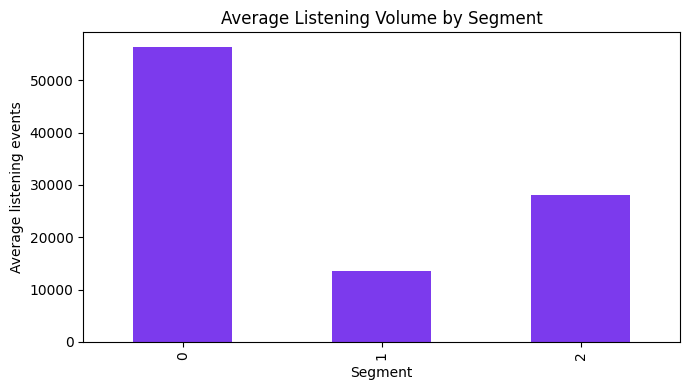

In [11]:
segment_summary = (
    segmented_users.groupBy('segment')
    .agg(
        F.count('*').alias('users'),
        F.round(F.avg('total_listens'), 2).alias('avg_total_listens'),
        F.round(F.avg('unique_artists'), 2).alias('avg_unique_artists'),
        F.round(F.avg('unique_tracks'), 2).alias('avg_unique_tracks'),
        F.round(F.avg('active_days'), 2).alias('avg_active_days'),
        F.round(F.avg('artist_diversity'), 4).alias('avg_artist_diversity'),
        F.round(F.avg('repeat_rate'), 4).alias('avg_repeat_rate'),
        F.round(F.avg('night_share'), 4).alias('avg_night_share'),
        F.round(F.avg('weekend_share'), 4).alias('avg_weekend_share'),
    )
    .orderBy('segment')
)

segment_summary_pd = segment_summary.toPandas()
display(segment_summary_pd)

def segment_label(row):
    if row['avg_total_listens'] == segment_summary_pd['avg_total_listens'].max():
        return 'Heavy listeners'
    if row['avg_artist_diversity'] == segment_summary_pd['avg_artist_diversity'].max():
        return 'Music explorers'
    if row['avg_repeat_rate'] == segment_summary_pd['avg_repeat_rate'].max():
        return 'Repeat-focused listeners'
    return 'Balanced listeners'

segment_summary_pd['suggested_label'] = segment_summary_pd.apply(segment_label, axis=1)
display(segment_summary_pd[['segment', 'users', 'suggested_label']])

ax = segment_summary_pd.plot(kind='bar', x='segment', y='avg_total_listens', legend=False, figsize=(7, 4), color='#7c3aed')
ax.set_title('Average Listening Volume by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Average listening events')
plt.tight_layout()
plt.show()

## 11. Save analytics outputs

In [12]:
summary_pd.to_csv(OUTPUT_DIR / 'part_a_dataset_summary.csv', index=False)
top_artists.to_csv(OUTPUT_DIR / 'part_a_top_artists.csv', index=False)
top_tracks.to_csv(OUTPUT_DIR / 'part_a_top_tracks.csv', index=False)
hourly_listens.to_csv(OUTPUT_DIR / 'part_a_hourly_listens.csv', index=False)
daily_listens.to_csv(OUTPUT_DIR / 'part_a_daily_listens.csv', index=False)
monthly_listens.to_csv(OUTPUT_DIR / 'part_a_monthly_listens.csv', index=False)
top_countries.to_csv(OUTPUT_DIR / 'part_a_top_countries.csv', index=False)
country_listens.to_csv(OUTPUT_DIR / 'part_a_country_listens.csv', index=False)
segment_summary_pd.to_csv(OUTPUT_DIR / 'part_a_segment_summary.csv', index=False)

segmented_users.select('user_id', 'segment', 'favorite_artist', *feature_columns).toPandas().to_csv(
    OUTPUT_DIR / 'part_a_user_segments.csv', index=False
)

print('Saved Part A analytics outputs in:', OUTPUT_DIR.resolve())

Saved Part A analytics outputs in: /Users/sahanpaymedia/Documents/Assignment BigData/outputs


## 12. Findings and interpretation

**Key findings to discuss after running:**

- The top artists and tracks reveal strong popularity concentration in the listening sample.
- Hourly and weekday patterns show when users are most active.
- Country-level counts show where Last.fm profile users are concentrated.
- User segmentation separates listeners by volume, diversity, repeat behavior, and listening time.

**Limitations:**

- The local demo uses 1,000,000 rows for stability, not the full 19,150,868 rows.
- The dataset is from 2009, so it does not represent current music trends.
- Country and demographic fields may be missing for some users.

**Possible improvements:**

- Run the notebook on the full dataset using a stronger machine or Spark cluster.
- Add artist tags, genres, or audio features for richer analytics.
- Compare clustering results for different values of K.
- Build a dashboard for interactive exploration.